Code to compare the theoretical gate-based approximation to the hardware results for NN couplings

In [ ]:
import os
import numpy as np
from braket.circuits import Circuit
from braket.devices import LocalSimulator
from braket.aws import AwsDevice
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks


[LOCAL SIMULATOR MODE]

Retrieving results...

[RESULT] t = 0.00 | fidelity = 0.000
[RESULT] t = 0.10 | fidelity = 0.000
[RESULT] t = 0.20 | fidelity = 0.000
[RESULT] t = 0.30 | fidelity = 0.000
[RESULT] t = 0.40 | fidelity = 0.003
[RESULT] t = 0.50 | fidelity = 0.010
[RESULT] t = 0.60 | fidelity = 0.022
[RESULT] t = 0.70 | fidelity = 0.037
[RESULT] t = 0.80 | fidelity = 0.083
[RESULT] t = 0.90 | fidelity = 0.225
[RESULT] t = 1.00 | fidelity = 0.360
[RESULT] t = 1.10 | fidelity = 0.512
[RESULT] t = 1.20 | fidelity = 0.675
[RESULT] t = 1.30 | fidelity = 0.810
[RESULT] t = 1.40 | fidelity = 0.932
[RESULT] t = 1.50 | fidelity = 0.963
[RESULT] t = 1.60 | fidelity = 0.960
[RESULT] t = 1.70 | fidelity = 0.812
[RESULT] t = 1.80 | fidelity = 0.700
[RESULT] t = 1.90 | fidelity = 0.515
[RESULT] t = 2.00 | fidelity = 0.305
[RESULT] t = 2.10 | fidelity = 0.160
[RESULT] t = 2.20 | fidelity = 0.070
[RESULT] t = 2.30 | fidelity = 0.013
[RESULT] t = 2.40 | fidelity = 0.005
[RESULT] t = 2.50 | fidelit

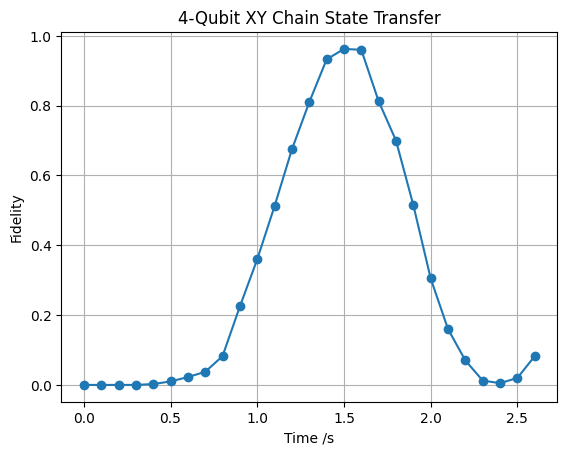

In [ ]:
# Gate-based Theoretical Simulations to compare processor results against
N_QUBITS = 4

os.environ["AWS_ACCESS_KEY_ID"]="access key ID"
os.environ["AWS_SECRET_ACCESS_KEY"]="access key"
os.environ["AWS_SESSION_TOKEN"]= "session token"
os.environ["AWS_DEFAULT_REGION"] = "region"
USE_IONQ_QPU = False


# XY interaction
def xy_interaction(circuit, q1, q2, theta):
    circuit.xx(q1, q2, theta)
    circuit.rz(q1, np.pi / 2)
    circuit.rz(q2, np.pi / 2)
    circuit.xx(q1, q2, theta)
    circuit.rz(q1, -np.pi / 2)
    circuit.rz(q2, -np.pi / 2)




# Trotter circuit
def xy_trotter_circuit(n_qubits, J, total_time, dt):
    trotter_steps = int(total_time / dt)
    theta = J * dt

    circuit = Circuit()

    # Initial state: excitation at last qubit
    circuit.x(n_qubits - 1)

    for _ in range(trotter_steps):
        for i in range(n_qubits - 1):
            xy_interaction(circuit, i, i + 1, theta)

    return circuit



# Device setup (only once)
if USE_IONQ_QPU:
    device = AwsDevice("device")
    print("\n[HARDWARE MODE]")
else:
    device = LocalSimulator()
    print("\n[LOCAL SIMULATOR MODE]")



# Run simulation
tasks = []
times = []

dt = 0.1
times = np.arange(0, 2.7, dt)

for time2 in times:

    circuit = xy_trotter_circuit(
        n_qubits=N_QUBITS,
        J=-2.0,
        total_time=time2,
        dt=dt
    )

    # Measure all qubits and add measurements
    for q in range(N_QUBITS):
        circuit.measure(q)

    task = device.run(circuit, shots=400)
    tasks.append(task)



# Get results
fidelities = []

print("\nRetrieving results...\n")

# target state = excitation moved to first qubit
target_state = "1" + "0" * (N_QUBITS - 1)

for time2, task in zip(times, tasks):
    result = task.result()
    counts = result.measurement_counts

    shots = sum(counts.values())
    fidelity = counts.get(target_state, 0) / shots if shots > 0 else 0

    fidelities.append(fidelity)

    print(f"[RESULT] t = {time2:.2f} | fidelity = {fidelity:.3f}")



# Plot
plt.figure()
plt.plot(times, fidelities, marker='o')
plt.xlabel("Time /s")
plt.ylabel("Fidelity")
plt.title(f"{N_QUBITS}-Qubit XY Chain State Transfer")
plt.grid(True)
plt.show()

Plot for varying system sizes with NN coupling


Retrieving results...


Retrieving results...


Retrieving results...



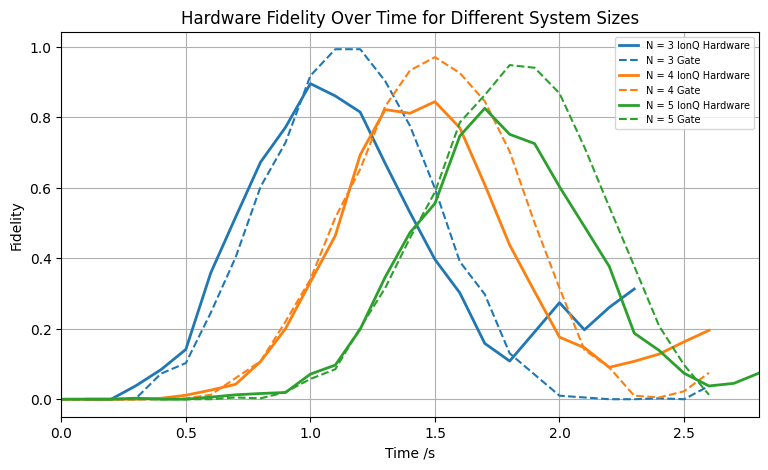

In [ ]:
# Loading Hardware results to compare to theoretical simulations
# Parameters
total_time = 6
J_in = 1.0
alpha = 5
ns_str = "5-20-50-100"
# Display n = 50
n_plot = int(ns_str.split("-")[2])


# Load hardware data
BASE_DIR = Path(
    r"Folder")
DATA_DIR = BASE_DIR / "Hardware Data"

Ls = [3,4,5]
# Plot
plt.figure(figsize=(9,5))


for L in Ls:
    file_name = f"fidelity_data400shots_L{L}_renorm.npz"
    file_path = DATA_DIR / file_name
    
    if not file_path.exists():
        print(f"Skipping L={L}: File not found ({file_name})")
        continue


    data_400 = np.load(file_path)
    time_400 = data_400["time"]

    key_initial = f"P_1{'0' * (L - 1)}_ren"
    P_400initial = data_400[key_initial]


    indices, _ = find_peaks(P_400initial, height=0.8)
    peak_indices = indices
    peak_times_hardware = time_400[peak_indices]
    peak_values_hardware = P_400initial[peak_indices]



    N_QUBITS = L 

    tasks = []
    times_gate = []

    dt = 0.1
    times_gate = np.arange(0, 2.7, dt)

    for time2 in times_gate:

        circuit = xy_trotter_circuit(
            n_qubits=N_QUBITS,
            J=-2.0,
            total_time=time2,
            dt=dt
        )

        # Measure all qubits
        # add measurements
        for q in range(N_QUBITS):
            circuit.measure(q)

        task = device.run(circuit, shots=400)
        tasks.append(task)


    
    # Get results
    
    fidelities_gate = []

    print("\nRetrieving results...\n")

    # target state = excitation moved to first qubit
    target_state = "1" + "0" * (N_QUBITS - 1)

    for time2, task in zip(times_gate, tasks):
        result = task.result()
        counts = result.measurement_counts

        shots = sum(counts.values())
        fidelity = counts.get(target_state, 0) / shots if shots > 0 else 0

        fidelities_gate.append(fidelity)

        #print(f"[RESULT] t = {time2:.2f} | fidelity = {fidelity:.3f}")
    

    # indices, _ = find_peaks(fidelities_gate, height=0.8)
    # peak_indices = indices
    # peak_times_gate = times_gate[peak_indices]
    # peak_values_gate = fidelities_gate[peak_indices]



    line, = plt.plot(time_400, P_400initial, lw=2, label=f"N = {L} IonQ Hardware")
    current_color = line.get_color()
    line, = plt.plot(times_gate, fidelities_gate,linestyle='--',color=current_color, label=f"N = {L} Gate")
    
    #print(f"Method: Gate NN, Peak Fidelity: {peak_values_gate} at {peak_times_gate}, Steps = {n_plot}")
    #print(f"L={L}, Hardware, Peak Fidelity: {peak_values_hardware} at {peak_times_hardware}")

plt.xlim(0,2.8)
plt.xlabel("Time /s")
plt.ylabel("Fidelity")
plt.title("Hardware Fidelity Over Time for Different System Sizes")
plt.legend(fontsize=7, loc="best")
plt.grid(True)
plt.show()